# Set-up libraries and dependencies

In [1]:
import os
from typing import Sequence, Dict, Union
from tqdm import tqdm
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset

try:
  import torch_geometric as gtorch

except ImportError:
  os.system('pip install torch_geometric -qq')
  os.system('pip install torch-scatter -qq')

import torch_geometric as gtorch
import torch_scatter

In [2]:
! pip install wandb
! pip install torch-cluster

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=2242565 sha256=26c4f335de978d3a9aa4bbf8c007482c2e2d57d1fdd1f08cf0594b903770ab29
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch-cluster


In [3]:
import wandb
import os
from torch_geometric.datasets import QM9
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [4]:
dataset = QM9(root='./data/QM9')

In [5]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Inspecting Dataset

In [6]:
# Check overall dataset properties
print(f"Dataset name: {dataset}")
print(f"Total number of molecules: {len(dataset)}")
print(f"Number of node features (atom properties): {dataset.num_node_features}")
print(f"Number of edge features (bond properties): {dataset.num_edge_features}")
print(f"Number of targets per molecule: {dataset.num_classes}")

Dataset name: QM9(130831)
Total number of molecules: 130831
Number of node features (atom properties): 11
Number of edge features (bond properties): 4
Number of targets per molecule: 19


In [7]:
# Inspecting single molecule

# First molecule in the dataset
data_sample = dataset[0]

print("--- Single Graph Representation ---")
print(data_sample)
print("\n--- Detailed Breakdown ---")
print(f"Number of atoms (nodes): {data_sample.num_nodes}")
print(f"Number of bonds (edges): {data_sample.num_edges}")
print(f"Node feature matrix 'x' shape: {data_sample.x.shape} -> (Nodes x Features)")
print(f"Edge index matrix 'edge_index' shape: {data_sample.edge_index.shape} -> (2 x Edges)")
print(f"Edge feature matrix 'edge_attr' shape: {data_sample.edge_attr.shape} -> (Edges x Features)")
print(f"Target vector 'y' shape: {data_sample.y.shape} -> (1 x Targets)")

--- Single Graph Representation ---
Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])

--- Detailed Breakdown ---
Number of atoms (nodes): 5
Number of bonds (edges): 8
Node feature matrix 'x' shape: torch.Size([5, 11]) -> (Nodes x Features)
Edge index matrix 'edge_index' shape: torch.Size([2, 8]) -> (2 x Edges)
Edge feature matrix 'edge_attr' shape: torch.Size([8, 4]) -> (Edges x Features)
Target vector 'y' shape: torch.Size([1, 19]) -> (1 x Targets)


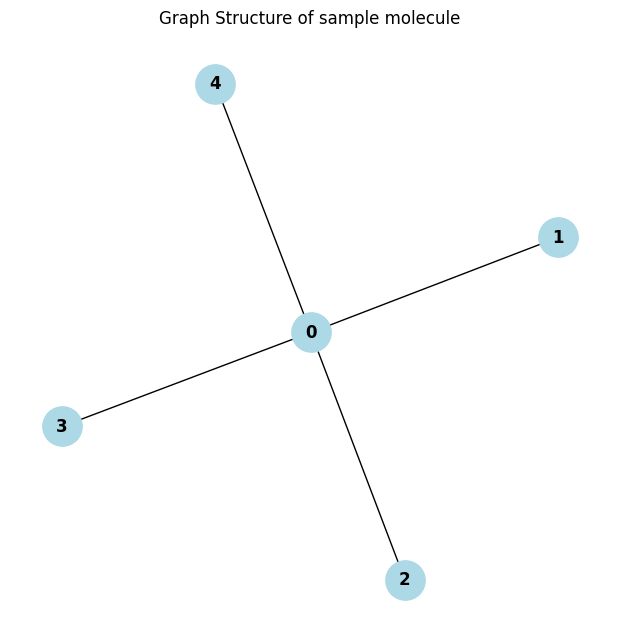

In [ ]:
# Visualising a molecule

import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# Convert the PyG graph to a NetworkX graph
# We use to_undirected=True because chemical bonds go both ways
nx_graph = to_networkx(data_sample, to_undirected=True)

# Plot it
plt.figure(figsize=(6, 6))
nx.draw(nx_graph,
        with_labels=True,
        node_color='lightblue',
        node_size=800,
        font_weight='bold')
plt.title("Graph Structure of sample molecule")
plt.show()

# Data Preparation for model training

In [8]:
dataset = dataset.shuffle() # shuffle dataset for train, test split later

# Train, val, Test split ratio: 80%, 10%, 10%
train_ratio = 0.8
num_train = int(len(dataset) * train_ratio)
num_val = int(len(dataset) * (1-train_ratio)/2)

train_dataset = dataset[:num_train]
val_dataset = dataset[num_train: num_train + num_val]
test_dataset = dataset[num_train + num_val: ]

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
TARGET_INDEX = 4 # Specify index for HOMO-LUMO gap

target_vals = torch.tensor([data.y[0, TARGET_INDEX].item() for data in train_dataset])

# Calculate mean and standard deviation
train_mean = target_vals.mean().to(device)
train_std = target_vals.std().to(device)

print(f"Target {TARGET_INDEX} - Mean: {train_mean:.4f}, Std: {train_std:.4f}")

Target 4 - Mean: 6.8596, Std: 1.2838


# Baseline: GNN

In [ ]:
import torch_geometric.nn as gnn
from typing import Sequence

class GNN(torch.nn.Module):
  def __init__(self,
               in_channels: int, # Number of input node features
               edge_attr_dim: int, # number of edge features
               gnn_channels: Sequence[int], # Output channels for each GNN layer
               add_self_loops: bool = True,
               pool: str = 'global_mean_pool',
               fc_channels: Sequence[int] = [], # hidden FC layer sizes
               activation: str = 'ReLU' # name of activation class
               ):
    super().__init__()

    # store activation function
    self.activation = getattr(nn, activation)()

    # ---- GNN Layers ----
    self.gnn_layers = nn.ModuleList()
    input_channels = in_channels

    for num_layers in gnn_channels:
      self.gnn_layers.append(gnn.conv.GCNConv(input_channels, num_layers, add_self_loops=add_self_loops))
      input_channels = num_layers

    # --- Edge Encoders ---
    # 1 encoder per GNN layer
    self.edge_encoder = nn.ModuleList([
        nn.Sequential(
            nn.Linear(in_features=edge_attr_dim, out_features=1),
            nn.Sigmoid(),
            nn.Flatten(0)
        ) for _ in range(len(self.gnn_layers))
    ])

    # -- Global Pooling --
    self.pool = getattr(gnn.pool, pool)

    # --- FC layers ---
    self.fc_layers = nn.ModuleList()
    current_channels = gnn_channels[-1]
    for fc in fc_channels:
      self.fc_layers.append(nn.Linear(current_channels, fc))
      current_channels = fc

    # --- Output Layer ---
    self.out_layer = nn.Linear(current_channels, 1)

  def forward(
      self,
      x: torch.FloatTensor,
      edge_index: torch.LongTensor,
      edge_attr: torch.FloatTensor,
      batch: torch.LongTensor
  ) -> torch.FloatTensor:

    # --- GNN Message Passing ---
    for i in range(len(self.gnn_layers)):
      edge_weight = self.edge_encoder[i](edge_attr)
      x = self.gnn_layers[i](x, edge_index, edge_weight)

    # --- Global Pooling ---
    x = self.pool(x, batch)

    # --- FC layers ---
    for layer in self.fc_layers:
      x = layer(x)
      x = self.activation(x)

    # --- Output ---
    x = self.out_layer(x)

    return x


In [ ]:
def train(model, cfg):
    model.train()
    total_loss = 0

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train_lr)
    criterion = torch.nn.L1Loss()

    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()

        # Forward pass
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        # Extract the raw target
        raw_target = data.y[:, cfg.target_index].unsqueeze(1)

        # Standardize the target
        standardized_target = (raw_target - train_mean) / train_std

        # Calculate loss against the standardized target
        loss = criterion(out, standardized_target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(train_loader.dataset)

In [ ]:
@torch.no_grad()
def test(loader, model, cfg):

    model.eval()
    total_error = 0

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train_lr)
    criterion = torch.nn.L1Loss()

    for data in loader:
        data = data.to(device)

        # The model outputs a standardized prediction
        standardized_out = model(data.x, data.edge_index, data.edge_attr, data.batch)

        # Un-standardize the prediction back to original units
        real_out = (standardized_out * train_std) + train_mean

        # Extract the raw target (do not standardize it here)
        raw_target = data.y[:, cfg.target_index].unsqueeze(1)

        # Calculate MAE in real units
        error = criterion(real_out, raw_target)
        total_error += error.item() * data.num_graphs

    return total_error / len(test_loader.dataset)

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

def run_experiment(experiment_config):
    # Initialize a new W&B run
    wandb.init(
        project="gnn-qm9-experiment-baseline",
        config=experiment_config,
        reinit=True # This tells W&B to allow multiple runs in one script
    )

    # wandb.config ensures your logged config matches what W&B recorded
    cfg = wandb.config


    print(f"\n--- Starting Experiment: LR={cfg.train_lr}, GNN Layers={cfg.model_gnn_channels} ---")

    # Initialize a FRESH model and optimizer for every experiment run
    model = GNN(
        in_channels=dataset.num_node_features,
        edge_attr_dim=dataset.num_edge_features,
        gnn_channels=cfg.model_gnn_channels,
        add_self_loops=True,
        pool=cfg.model_pool,
        fc_channels=cfg.model_fc_channels,
        activation=cfg.model_activation
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.train_lr)
    criterion = torch.nn.L1Loss()

    # The Training Loop
    cfg.update({"target_index": TARGET_INDEX}) # For HOMO - LUMO

    history_train_loss = []
    history_val_mae = []
    epochs_range = []

    print("Starting training for HOMO-LUMO gap...")

    best_val_mae = float('inf')

    for epoch in tqdm(range(1, cfg.train_epochs + 1), desc="Training Progress"):
        # Run training and validation
        train_loss = train(model, cfg)
        val_mae = test(val_loader, model, cfg)

        # Store the metrics
        epochs_range.append(epoch)
        history_train_loss.append(train_loss)
        history_val_mae.append(val_mae)

        # Log to WandB
        wandb.log({"epoch": epoch, "train_loss": train_loss, "val_mae": val_mae})

        if val_mae < best_val_mae:
            best_val_mae = val_mae

            # Create a dictionary containing everything we want to save
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(), # The actual learned weights
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_mae': best_val_mae,
                'config': dict(cfg) # The W&B config dictionary
            }

            # Save locally to Colab
            checkpoint_path = f"best_model_{cfg.experiment_name}.pt"
            torch.save(checkpoint, checkpoint_path)

            # Tell W&B to upload this file to your cloud dashboard
            wandb.save(checkpoint_path)

        clear_output(wait=True)

        plt.figure(figsize=(10, 5))
        plt.plot(epochs_range, history_train_loss, label='Train Loss (Standardized)', color='blue', marker='o', markersize=4)
        plt.plot(epochs_range, history_val_mae, label='Validation MAE (eV)', color='orange', marker='o', markersize=4)

        plt.title(f'HOMO-LUMO Gap (Epoch {epoch}/{cfg.train_epochs})', fontweight='bold')
        plt.xlabel('Epochs')
        plt.ylabel('MAE (eV)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

        # Display the plot
        plt.show()

        # Print the current stats right below the live plot
        print(f'Epoch: {epoch} | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f} eV')

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch: {epoch}, Train Loss (Standardized): {train_loss:.4f}, Val MAE (eV): {val_mae:.4f}')



      # 4. Final Evaluation & Cleanup

    print(f"\nLoading best model from epoch with Val MAE: {best_val_mae:.4f}")
    checkpoint_path = f"best_model_{cfg.experiment_name}.pt"
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Now evaluate on the test set

    test_mae = test(test_loader, model, cfg)
    print(f'\nTraining Complete! Final Test MAE: {test_mae:.4f} eV')
    wandb.log({"test_mae": test_mae})

    # End the run so the next one can start cleanly
    wandb.finish()

In [ ]:
# A list of different configurations to test


experiments_to_run = [
    # ---------------------------------------------------------
    # Experiment 1
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 1",
        "model_in_channels": data_sample.x.shape[1],
        "model_edge_attr_dim": data_sample.edge_attr.shape[1],
        "model_gnn_channels": [64, 64],
        "model_fc_channels": [32],
        "model_pool": "global_mean_pool",
        "model_activation": "ReLU",

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 64,
        "train_lr": 0.001

    },

    # ---------------------------------------------------------
    # Experiment 2
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 2",
        "model_in_channels": data_sample.x.shape[1],
        "model_edge_attr_dim": data_sample.edge_attr.shape[1],
        "model_gnn_channels": [128, 128, 128],
        "model_fc_channels": [64, 32],
        "model_pool": "global_mean_pool",
        "model_activation": "SiLU",

        "train_optimizer_name": 'Adam',
        "train_lr": 0.0005,
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 64,


    },

    # ---------------------------------------------------------
    # Experiment 3
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 3",
        "model_in_channels": data_sample.x.shape[1],
        "model_edge_attr_dim": data_sample.edge_attr.shape[1],
        "model_gnn_channels": [64, 64],
        "model_pool": "global_mean_pool",
        "model_fc_channels": [32],
        "model_activation": "ReLU",

        "train_optimizer_name": 'Adam',
        "train_lr": 0.005,
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_batch_size": 256,
        "train_epochs": 50,

    },

    # ---------------------------------------------------------
    # Experiment 4
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 4",
        "model_in_channels": data_sample.x.shape[1],
        "model_edge_attr_dim": data_sample.edge_attr.shape[1],
        "model_gnn_channels": [128, 128],
        "model_pool": "global_max_pool",
        "model_fc_channels": [128, 64, 32], # Funnel shape
        "model_activation": "SiLU",

        "train_optimizer_name": 'Adam',
        "train_lr": 0.001,
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_batch_size": 128,
        "train_epochs": 50,

    },
    # ---------------------------------------------------------
    # Experiment 5
    # ---------------------------------------------------------

    {   "experiment_name": "Experiment 5",
        "model_in_channels": data_sample.x.shape[1],
        "model_edge_attr_dim": data_sample.edge_attr.shape[1],
        "model_gnn_channels": [64, 128],
        "model_pool": 'global_add_pool',
        "model_fc_channels": [64, 32],
        "model_activation": 'ReLU',

        "train_optimizer_name": 'Adam',
        "train_lr": 0.001,
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_batch_size": 64,
        "train_epochs": 50}
]


In [ ]:
# Run experiments sequentially
for config in experiments_to_run:
    run_experiment(config)

In [ ]:
# For clearing directory
# import os
# import glob

# # Remove all files in the working directory
# files = glob.glob('/kaggle/working/*')
# for f in files:
#     if os.path.isfile(f):
#         os.remove(f)


# Variant : Dimenet (https://arxiv.org/abs/2003.03123)

In [10]:
# Import utils files from Dimnet

!git clone https://github.com/gasteigerjo/dimenet.git

Cloning into 'dimenet'...
remote: Enumerating objects: 627, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 627 (delta 5), reused 2 (delta 0), pack-reused 614 (from 1)
Receiving objects: 100% (627/627), 222.52 MiB | 22.90 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (146/146), done.


In [12]:
import sys
sys.path.append('/content/dimenet')

# %cd dimenet

# Checkout the specific commit you were looking at
# !git checkout 66a8168ddb3c6e972977c7fb7d2143d6baee1402

In [ ]:
import sys
import os

# 1. Force the notebook back to the absolute base directory
%cd /content/dimenet

# 2. Purge any deep folders from your path to prevent name collisions
# bad_paths = [
#     '/kaggle/working/dimenet/dimenet/model',
#     '/kaggle/working/dimenet/dimenet/model/layers',
#     '/kaggle/working/dimenet/dimenet'
# ]
# sys.path = [p for p in sys.path if p not in bad_paths]

# # 3. Add ONLY the true root of the repository
# if '/kaggle/working/dimenet' not in sys.path:
#     sys.path.insert(0, '/kaggle/working/dimenet')


/content/dimenet


In [ ]:
!pip install -U jax jaxlib

In [ ]:
!pip install torch-cluster

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 670.6 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=818327 sha256=f989914372a83fe353ca95c2e27a7f40fcf1a70578d4c53586f5d4c035ee2e48
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch-cluster


In [23]:
from dimenet.model.layers.envelope import Envelope
from dimenet.model.layers.basis_utils import bessel_basis, real_sph_harm
import math
np.math = math
from torch_cluster import radius_graph

In [ ]:
# Define BeselBasis Layer

import torch
import torch.nn as nn
import numpy as np

class BesselBasisLayer(nn.Module):
    def __init__(self, num_radial, cutoff, envelope_exponent=5):
        super().__init__()
        self.num_radial = num_radial
        self.inv_cutoff = 1.0 / cutoff
        self.envelope = Envelope(envelope_exponent)

        # Initialize frequencies as a trainable PyTorch Parameter
        freq_init = torch.arange(1, num_radial + 1, dtype=torch.float32) * np.pi
        self.frequencies = nn.Parameter(freq_init)

    def forward(self, inputs):
        d_scaled = inputs * self.inv_cutoff

        d_scaled = d_scaled.unsqueeze(-1)

        d_cutoff = self.envelope(d_scaled)
        return d_cutoff * torch.sin(self.frequencies * d_scaled)

In [ ]:
# Define SphericalBasisLayer

import sympy as sym
import torch
import torch.nn as nn

class SphericalBasisLayer(nn.Module):
    def __init__(self, num_spherical, num_radial, cutoff, envelope_exponent=5):
        super().__init__()
        assert num_radial <= 64
        self.num_radial = num_radial
        self.num_spherical = num_spherical

        self.inv_cutoff = 1.0 / cutoff
        self.envelope = Envelope(envelope_exponent)

        # Retrieve formulas
        self.bessel_formulas = bessel_basis(num_spherical, num_radial)
        self.sph_harm_formulas = real_sph_harm(num_spherical)
        self.sph_funcs = []
        self.bessel_funcs = []

        x = sym.symbols('x')

        torch_modules = {'sin': torch.sin, 'cos': torch.cos, 'sqrt': torch.sqrt, 'exp': torch.exp}

        theta = sym.symbols('theta')

        # When moving this to PyTorch, you map Sympy functions to Torch functions here
        # Example mapping: modules=[{'sin': torch.sin, 'cos': torch.cos, ...}]
        for i in range(num_spherical):
            if i == 0:
                first_sph = float(sym.lambdify([theta], self.sph_harm_formulas[i][0], 'numpy')(0))
                self.sph_funcs.append(lambda tensor: torch.zeros_like(tensor) + first_sph)
            else:
                self.sph_funcs.append(sym.lambdify([theta], self.sph_harm_formulas[i][0], modules=torch_modules)) # Or a custom torch dictionary
            for j in range(num_radial):
                self.bessel_funcs.append(sym.lambdify([x], self.bessel_formulas[i][j], modules=torch_modules))

    def forward(self, inputs):
        # PyTorch passes multiple inputs natively as a tuple
        d, Angles, id_expand_kj = inputs

        d_scaled = d * self.inv_cutoff

        # Calculate rbf
        rbf = [f(d_scaled) for f in self.bessel_funcs]
        rbf = torch.stack(rbf, dim=1) # tf.stack(..., axis=1)

        d_cutoff = self.envelope(d_scaled)

        # d_cutoff[:, None] becomes d_cutoff.unsqueeze(1)
        rbf_env = d_cutoff.unsqueeze(1) * rbf

        # tf.gather becomes standard indexing
        rbf_env = rbf_env[id_expand_kj]

        # Calculate cbf
        cbf = [f(Angles) for f in self.sph_funcs]
        cbf = torch.stack(cbf, dim=1)

        # tf.repeat becomes torch.repeat_interleave
        cbf = torch.repeat_interleave(cbf, self.num_radial, dim=1)

        return rbf_env * cbf

In [10]:
# Dimenet architecture

import torch
from torch_geometric.nn.models import DimeNet as PyGDimeNet
from torch_cluster import radius_graph

class DimeNet(torch.nn.Module):
    def __init__(self, emb_size, num_blocks, num_bilinear, num_spherical,
                 num_radial, cutoff, envelope_exponent, num_before_skip,
                 num_after_skip, num_dense_output, num_targets, **kwargs):
        super(DimeNet, self).__init__()

        # We map your specific config names to the PyG DimeNet++ implementation
        self.model = PyGDimeNet(
            hidden_channels=emb_size,
            out_channels=num_targets,
            num_blocks=num_blocks,
            num_bilinear=num_bilinear,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
            envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip,
            num_after_skip=num_after_skip,
            num_output_layers=num_dense_output
        )

    def forward(self, z, pos, batch):
        # Your prepare_dimenet_inputs output must match these inputs
        return self.model(z, pos, batch)

In [ ]:
!pip install torch-cluster

In [11]:
def train(model, loader, optimizer, criterion, device, target_idx=4):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()

        # PyG DimeNet takes (z, pos, batch) directly.
        # No more custom 'prepare_dimenet_inputs' needed!
        out = model(data.z, data.pos, data.batch)

        target_val = data.y[:, target_idx]
        loss = criterion(out.squeeze(), target_val)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

    return total_loss / len(loader.dataset)


def test(model, loader, criterion, device, target_idx=4):
    model.eval()
    total_error = 0

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            # Match the same forward pass format as train
            out = model(data.z, data.pos, data.batch)

            target_val = data.y[:, target_idx]
            error = criterion(out.squeeze(), target_val)
            total_error += error.item() * data.num_graphs

    return total_error / len(loader.dataset)

In [16]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.auto import tqdm

def run_experiment(config=None):
    # 1. Initialize W&B run
    # Set the project name to whatever you want it called on your dashboard
    with wandb.init(project="dimenet-qm9-experiments-2", config=config):
        config = wandb.config
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # 2. Load Dataset
        dataset = QM9(root='data/QM9')
        # Split: 10k train, 1k test is fine for debugging
        train_loader = DataLoader(dataset[:10000], batch_size=config.train_batch_size, shuffle=True)
        test_loader = DataLoader(dataset[10000:11000], batch_size=config.train_batch_size, shuffle=False)

        # 3. Initialize Model
        # Use the bridge class we defined in the previous step
        model = DimeNet(
            emb_size=config.emb_size,
            num_blocks=config.num_blocks,
            num_bilinear=8,
            num_spherical=7,
            num_radial=6,
            cutoff=config.cutoff,
            envelope_exponent=5,
            num_before_skip=1,
            num_after_skip=2,
            num_dense_output=3,
            num_targets=1
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=config.train_lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=config.train_scheduler_factor, patience=config.train_scheduler_patience
        )
        criterion = torch.nn.L1Loss()

        # 4. Set up Checkpointing Variables
        best_mae = float('inf')
        save_dir = "checkpoints"
        os.makedirs(save_dir, exist_ok=True)
        model_save_path = os.path.join(save_dir, f"best_dimenet_run_{wandb.run.id}.pth")

        train_losses = []
        test_maes = []

        # 5. The Training Loop
        for epoch in range(1, config.train_epochs + 1):

            # Run train and test (Target 4 is HOMO-LUMO gap)
            train_loss = train(model, train_loader, optimizer, criterion, device, target_idx=4)
            test_mae = test(model, test_loader, criterion, device, target_idx=4)

            scheduler.step(test_mae)

            print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test MAE: {test_mae:.4f}")

            train_losses.append(train_loss)
            test_maes.append(test_mae)

            # 6. Log metrics to W&B Dashboard
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "test_mae": test_mae,
                "learning_rate": optimizer.param_groups[0]['lr']
            })

            # 7. Model Checkpointing: Save if it's the best score so far
            if test_mae < best_mae:
                print(f"New best MAE! ({best_mae:.4f} --> {test_mae:.4f}). Saving model...")
                best_mae = test_mae

                # Save locally
                torch.save(model.state_dict(), model_save_path)

        print("Generating loss plots...")
        plt.figure(figsize=(10, 6))

        # Plot both metrics
        epochs_range = range(1, config.train_epochs + 1)
        plt.plot(epochs_range, train_losses, label='Train Loss (MAE)', color='blue', marker='o', markersize=4)
        plt.plot(epochs_range, test_maes, label='Test MAE', color='orange', marker='s', markersize=4)

        # Format the graph
        plt.title(f"DimeNet QM9 Training Progress\nRun ID: {wandb.run.id}")
        plt.xlabel('Epochs')
        plt.ylabel('Error (eV)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()
        plt.tight_layout()

        # Save the plot locally
        plot_save_path = f"train_loss{config.experiment_name}.png"
        plt.savefig(plot_save_path, dpi=300)
        plt.close() # Free memory
        print(f"Plot saved locally to: {plot_save_path}")

        # At the end of the run, upload the best model directly to W&B cloud storage
        wandb.save(model_save_path)
        print(f"Run completed. Best Test MAE: {best_mae:.4f}")

        print(f"\nLoading best model weights from: {model_save_path}")

        # Load the raw weights directly (no ['model_state_dict'] key needed)
        model.load_state_dict(torch.load(model_save_path))

        # Evaluate on the test set using DimeNet's specific test() arguments
        final_test_mae = test(model, test_loader, criterion, device, target_idx=4)
        print(f'Training Complete! Final Evaluated Test MAE: {final_test_mae:.4f} eV')

        # Log to W&B as a distinct metric so it doesn't get confused with the epoch loops
        wandb.log({"final_best_test_mae": final_test_mae})


In [13]:
experiments_to_run = [
    # ---------------------------------------------------------
    # Experiment 1 (Baseline: 2 Layers, Narrow)
    # GNN was: channels [64, 64], fc [32], BS 64
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 1_Baseline",
        "emb_size": 64,
        "num_blocks": 2,             # Corresponds to 2 GNN layers
        "num_dense_output": 1,       # Corresponds to 1 FC layer

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 32,      # Scaled down for DimeNet memory limits
        "train_lr": 0.001,
        "cutoff": 5.0
    },

    # ---------------------------------------------------------
    # Experiment 2 (Deeper & Wider)
    # GNN was: channels [128, 128, 128], fc [64, 32], BS 64, lower LR
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 2_Deep_Wide",
        "emb_size": 128,
        "num_blocks": 3,             # 3 message passing blocks
        "num_dense_output": 2,       # 2 FC layers in the output block

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 32,
        "train_lr": 0.0005,          # Lower LR for deeper network
        "cutoff": 5.0
    },

    # ---------------------------------------------------------
    # Experiment 3 (High LR, "Large" Batch)
    # GNN was: BS 256, LR 0.005
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 3_High_LR_Large_Batch",
        "emb_size": 64,
        "num_blocks": 2,
        "num_dense_output": 1,

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 64,      # Pushing the memory limit for "large" batch
        "train_lr": 0.005,           # Aggressive learning rate
        "cutoff": 5.0
    },

    # ---------------------------------------------------------
    # Experiment 4 (Wide, Deep FC Funnel)
    # GNN was: channels [128, 128], fc [128, 64, 32]
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 4_Wide_Deep_FC",
        "emb_size": 128,
        "num_blocks": 2,
        "num_dense_output": 3,       # Deep funnel in the output blocks

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 32,
        "train_lr": 0.001,
        "cutoff": 5.0
    },

    # ---------------------------------------------------------
    # Experiment 5 (Standard with different embedding)
    # GNN was: channels [64, 128], add pool
    # ---------------------------------------------------------
    {
        "experiment_name": "Experiment 5_Standard",
        "emb_size": 128,             # DimeNet requires consistent embedding sizes
        "num_blocks": 2,
        "num_dense_output": 2,

        "train_optimizer_name": 'Adam',
        "train_lr_scheduler_name": 'ReduceLROnPlateau',
        "train_scheduler_factor": 0.5,
        "train_scheduler_patience": 10,
        "train_epochs": 50,
        "train_batch_size": 32,
        "train_lr": 0.001,
        "cutoff": 5.0
    }
]

In [ ]:
# import torch

# # Get versions for the download URL
# TORCH = torch.__version__.split('+')[0]
# CUDA = torch.version.cuda.replace('.', '')

# # Install the specific binary
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

# # Verification
# try:
#     import torch_sparse
#     print("✅ Success! torch-sparse is installed and linked.")
# except ImportError:
#     print("Still failing. You may need to Restart Session (Run > Restart Session) and then run this cell again.")


In [ ]:
!pip install torch-sparse

In [21]:
import importlib
import torch_cluster
import torch_geometric.typing

# 1. Force Python to reload the specific PyG module that handles dependencies
importlib.reload(torch_geometric.typing)

# 2. Surgically overwrite the dummy error-throwing class with the real library
torch_geometric.typing.torch_cluster = torch_cluster
torch_geometric.typing.WITH_TORCH_CLUSTER = True

print("PyG has been successfully hot-patched!")

PyG has been successfully hot-patched!


In [25]:
# 1. Uninstall any broken versions first
!pip uninstall -y torch-cluster torch-scatter torch-sparse torch-spline-conv torch-geometric

# 2. Get the exact PyTorch and CUDA versions
import torch
import os
torch_version = torch.__version__.split('+')[0]
cuda_version = torch.version.cuda.replace('.', '')

# 3. Install the core PyG library
!pip install torch-geometric

# 4. Install the dependencies using the specific wheel index
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-{torch_version}+cu{cuda_version}.html

Found existing installation: torch_cluster 1.6.3
Uninstalling torch_cluster-1.6.3:
  Successfully uninstalled torch_cluster-1.6.3
Found existing installation: torch_scatter 2.1.2
Uninstalling torch_scatter-2.1.2:
  Successfully uninstalled torch_scatter-2.1.2
Found existing installation: torch-geometric 2.7.0
Uninstalling torch-geometric-2.7.0:
  Successfully uninstalled torch-geometric-2.7.0
  Using cached torch_geometric-2.7.0-py3-none-any.whl.metadata (63 kB)
Using cached torch_geometric-2.7.0-py3-none-any.whl (1.3 MB)
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 62.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 70.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 79.4 MB/s eta 0:00:00


In [ ]:
import os
if __name__ == "__main__":
    # Ensure all your functions (train, test, prepare_dimenet_inputs)
    # and the DimeNet class are defined above this.

    print(f"Found {len(experiments_to_run)} experiments. Starting suite...")

    for config in experiments_to_run:
        print(f"\n{'='*50}")
        print(f"LAUNCHING: {config['experiment_name']}")
        print(f"{'='*50}")

        # Pass the current dictionary to our runner function
        run_experiment(config=config)

In [ ]:
import os
import glob

# Remove all files in the working directory
files = glob.glob('/kaggle/working/*')
for f in files:
    if os.path.isfile(f):
        os.remove(f)

1. Your full codebase used for data loading, training, and evaluation. There is no requirement
on code structure or style, but readability is appreciated.

2. A README.md that explains:
• How to set up the environment (dependencies, data download instructions).
• How to reproduce the key results from your report.

3. A reproduce results script or notebook that loads your trained model checkpoint(s) and
regenerates the key figures and metrics reported in your paper. The teaching team should be
able to run this without retraining from scratch, so please save your model checkpoint files.

# Latent Space analysis with t-SNE

In [ ]:
from collections import OrderedDict

# Purge all leftover hooks from previous crashes
for module in model_dimenet.modules():
    module._forward_hooks = OrderedDict()
    module._forward_pre_hooks = OrderedDict()

print("Hooks successfully purged!")

Hooks successfully purged!


In [ ]:
# Instantiate the blank architectures first

# Experiment 4 best MAE (GNN)
model_gnn = GNN(
        in_channels=dataset.num_node_features,
        edge_attr_dim=dataset.num_edge_features,
        gnn_channels=[128, 128],
        add_self_loops=True,
        pool="global_max_pool",
        fc_channels=[128, 64, 32],
        activation="SiLU"
    )


# Experiment 5 Best MAE (DimeNet)
model_dimenet = DimeNet(
            emb_size= 128,
            num_blocks= 2,
            num_bilinear=8,
            num_spherical=7,
            num_radial=6,
            cutoff= 5.0,
            envelope_exponent=5,
            num_before_skip=1,
            num_after_skip=2,
            num_dense_output=3,
            num_targets=1
        )

# Load Best-trained models
checkpoint_dimenet = torch.load("/content/checkpoints_best_dimenet_run_dsogz7xo.pth", map_location=device, weights_only=False)
checkpoint_gnn = torch.load("/content/best_model_Experiment 4 (1).pt", map_location=device, weights_only=False)

model_gnn.load_state_dict(checkpoint_gnn["model_state_dict"])
print("GNN Checkpoint loaded successfully!")

model_dimenet.load_state_dict(checkpoint_dimenet)
print("DimeNet Checkpoint loaded successfully!")

model_gnn.eval()
model_dimenet.eval()

GNN Checkpoint loaded successfully!
DimeNet Checkpoint loaded successfully!


DimeNet(
  (model): DimeNet(
    (rbf): BesselBasisLayer(
      (envelope): Envelope()
    )
    (sbf): SphericalBasisLayer(
      (envelope): Envelope()
    )
    (emb): EmbeddingBlock(
      (emb): Embedding(95, 128)
      (lin_rbf): Linear(in_features=6, out_features=128, bias=True)
      (lin): Linear(in_features=384, out_features=128, bias=True)
    )
    (output_blocks): ModuleList(
      (0-2): 3 x OutputBlock(
        (lin_rbf): Linear(in_features=6, out_features=128, bias=False)
        (lins): ModuleList(
          (0-2): 3 x Linear(in_features=128, out_features=128, bias=True)
        )
        (lin): Linear(in_features=128, out_features=1, bias=False)
      )
    )
    (interaction_blocks): ModuleList(
      (0-1): 2 x InteractionBlock(
        (lin_rbf): Linear(in_features=6, out_features=128, bias=False)
        (lin_sbf): Linear(in_features=42, out_features=8, bias=False)
        (lin_kj): Linear(in_features=128, out_features=128, bias=True)
        (lin_ji): Linear(in_f

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool  # We need this to manually pool DimeNet++

# =====================================================================
# LATENT SPACE EXTRACTOR
# =====================================================================
from torch_geometric.nn import global_mean_pool
import numpy as np
import torch


def extract_embeddings_final(model, loader, device, model_type="gnn", layer_name=""):
    model.eval()
    final_embeddings = []
    targets = []
    temp_storage = []

    def hook_fn(module, input_tuple, output):
        if model_type == "dimenet++":
            x = input_tuple[0].detach().cpu() # High-D edges
            i = input_tuple[2].detach().cpu() # Atom assignments
            temp_storage.append((x, i))
        else:
            out = output[0] if isinstance(output, tuple) else output

            # THE TRICK: If the layer crushes data down to 1 dimension (prediction)
            if out.ndim == 1 or out.shape[-1] == 1:
                # Steal the rich, high-dimensional INPUT instead!
                in_feat = input_tuple[0]
                if isinstance(in_feat, tuple):
                    in_feat = in_feat[0]
                temp_storage.append(in_feat.detach().cpu())
            else:
                # Otherwise, grab the output as usual
                temp_storage.append(out.detach().cpu())

    target_layer = None
    target_name = ""

    if model_type == "dimenet++":
        # THE FIX: Use 'in' to catch 'model.output_blocks.0'
        for name, module in model.named_modules():
            if "output_blocks.0" in name:
                target_layer = module
                target_name = name
                break
    else:
        for name, module in model.named_modules():
            if layer_name and layer_name == name:
                target_layer = module
                target_name = name
                break

    if target_layer is None:
        raise ValueError(f"Could not find the target layer for {model_type}! Check layer_name.")

    print(f"[{model_type}] Hook successfully attached to: {target_name}")
    hook_handle = target_layer.register_forward_hook(hook_fn)

    print(f"Extracting {model_type} embeddings... This may take a moment.")
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            if model_type == "dimenet++":
                _ = model(data.z, data.pos, data.batch)
                x, i = temp_storage.pop()
                edge_batch = data.batch.cpu()[i]
                graph_embs = global_mean_pool(x, edge_batch)
                final_embeddings.append(graph_embs.numpy())

            else:
                _ = model(data.x, data.edge_index, data.edge_attr, data.batch)
                graph_embs = temp_storage.pop()
                final_embeddings.append(graph_embs.numpy())

            targets.append(data.y[:, 4].cpu().numpy())

    hook_handle.remove()
    return np.concatenate(final_embeddings, axis=0), np.concatenate(targets, axis=0)


# =====================================================================
# t-SNE PLOTTING FUNCTION
# =====================================================================
def plot_latent_space_comparison(gnn_embeddings, gnn_targets, dimenet_embeddings, dimenet_targets):

    print("Computing t-SNE for GNN...")
    tsne_gnn = TSNE(n_components=2, perplexity=30, random_state=42)
    gnn_2d = tsne_gnn.fit_transform(gnn_embeddings)

    print("Computing t-SNE for DimeNet++...")
    tsne_dimenet = TSNE(n_components=2, perplexity=30, random_state=42)
    dimenet_2d = tsne_dimenet.fit_transform(dimenet_embeddings)

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot GNN
    sc1 = axes[0].scatter(
        gnn_2d[:, 0], gnn_2d[:, 1],
        c=gnn_targets, cmap='viridis',
        s=15, alpha=0.7, edgecolors='none'
    )
    axes[0].set_title("Standard GNN Latent Space", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    fig.colorbar(sc1, ax=axes[0], label="HOMO-LUMO Gap (eV)")

    # Plot DimeNet++
    sc2 = axes[1].scatter(
        dimenet_2d[:, 0], dimenet_2d[:, 1],
        c=dimenet_targets, cmap='viridis',
        s=15, alpha=0.7, edgecolors='none'
    )
    axes[1].set_title("DimeNet++ Latent Space", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("t-SNE Dimension 1")

    fig.colorbar(sc2, ax=axes[1], label="HOMO-LUMO Gap (eV)")

    plt.tight_layout()
    plt.savefig("latent_space_comparison.png", dpi=300)
    print("Plot saved as 'latent_space_comparison.png'!")
    plt.show()




In [ ]:
import torch_geometric.typing
import torch_cluster
import torch_scatter
import torch_sparse

# 1. Flip all the internal PyG activation switches
torch_geometric.typing.WITH_TORCH_CLUSTER = True
torch_geometric.typing.WITH_TORCH_SCATTER = True
torch_geometric.typing.WITH_TORCH_SPARSE = True

# 2. Inject the real libraries directly into PyG's typing module
torch_geometric.typing.torch_cluster = torch_cluster
torch_geometric.typing.torch_scatter = torch_scatter
torch_geometric.typing.torch_sparse = torch_sparse

# 3. Surgically overwrite all three dummy error-throwing classes
torch_geometric.typing.TorchCluster.__getattr__ = lambda self, key: getattr(torch_cluster, key)
# torch_geometric.typing.TorchScatter.__getattr__ = lambda self, key: getattr(torch_scatter, key)
# torch_geometric.typing.TorchSparse.__getattr__ = lambda self, key: getattr(torch_sparse, key)

print("SUCCESS: All 3 C++ backend libraries have been fully hot-patched into PyG!")

SUCCESS: All 3 C++ backend libraries have been fully hot-patched into PyG!


--- Analyzing GNN ---
[gnn] Hook successfully attached to: out_layer
Extracting gnn embeddings... This may take a moment.
--- Analyzing DimeNet++ ---
[dimenet++] Hook successfully attached to: model.output_blocks.0
Extracting dimenet++ embeddings... This may take a moment.
Computing t-SNE for GNN...
Computing t-SNE for DimeNet++...
Plot saved as 'latent_space_comparison.png'!


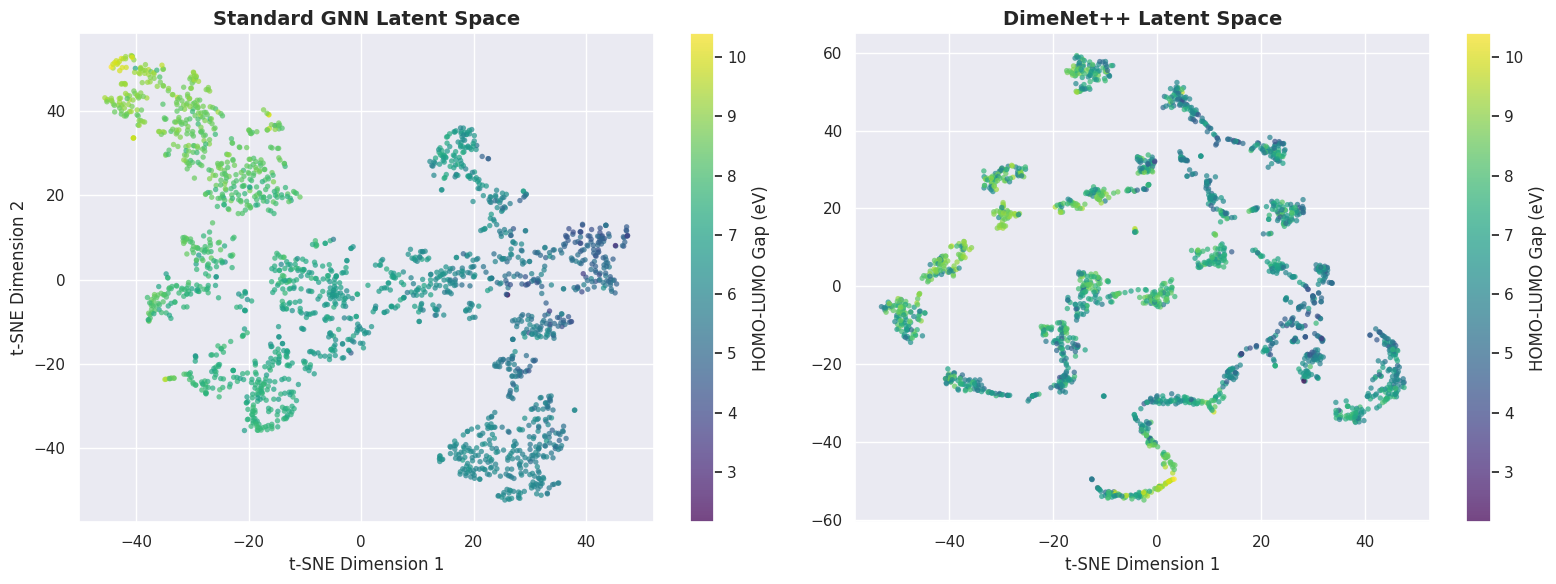

In [ ]:
# =====================================================================
# EXECUTION SCRIPT
# =====================================================================
import torch_cluster
from torch_cluster import radius_graph

if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Grab a subset for visualization
    test_loader = DataLoader(dataset[10000:12000], batch_size=64, shuffle=False)

    model_gnn = model_gnn.to(device)
    model_dimenet = model_dimenet.to(device)


    print("--- Analyzing GNN ---")
    # Point this to your GNN's global pooling layer or first fully connected layer
    gnn_layer_name = list(model_gnn.named_children())[-1][0]

    gnn_emb, gnn_y = extract_embeddings_final(
        model_gnn, test_loader, device,
        model_type="gnn",
        layer_name=gnn_layer_name
    )

    print("--- Analyzing DimeNet++ ---")
    # For PyG DimeNetPlusPlus, "output_blocks" will naturally find the output blocks
    # and our script will grab the atom embeddings right before the final block processes them.


    dimenet_emb, dimenet_y = extract_embeddings_final(
    model_dimenet, test_loader, device,
    model_type="dimenet++"
)

    plot_latent_space_comparison(gnn_emb, gnn_y, dimenet_emb, dimenet_y)